In [13]:
import pandas as pd
import glob
import os

# Path to the parent folder containing subfolders of csv files
base_path = "end_effector_coords"

# Get all csv files from subfolders
csv_files = glob.glob(os.path.join(base_path, "**", "*.csv"), recursive=True)

csv_files

# retrieve rewards

rewards_df = pd.read_csv('reward_df.csv')



In [14]:
# Dictionary to hold DataFrames with their names
dataframes = {}

for file in csv_files:
    parent = os.path.dirname(file)
    # folder = os.path.basename(os.path.dirname(file))   # parent folder name
    filename = os.path.splitext(os.path.basename(file))[0]  # csv name without extension
    # df_name = f"{folder}_{filename}"
    
    dataframes[filename] = pd.read_csv(file)

# Example: access one DataFrame
keys = list(dataframes.keys())
print(keys)   # shows all dataframe names
print(dataframes[keys[0]].head())

['active_1', 'active_10', 'active_11', 'active_12', 'active_13', 'active_14', 'active_15', 'active_16', 'active_17', 'active_18', 'active_19', 'active_2', 'active_20', 'active_21', 'active_22', 'active_23', 'active_25', 'active_26', 'active_27', 'active_28', 'active_29', 'active_3', 'active_30', 'active_31', 'active_32', 'active_33', 'active_34', 'active_4', 'active_5', 'active_6', 'active_7', 'active_8', 'active_9', 'passive_1', 'passive_10', 'passive_11', 'passive_12', 'passive_13', 'passive_14', 'passive_15', 'passive_16', 'passive_17', 'passive_18', 'passive_19', 'passive_2', 'passive_20', 'passive_3', 'passive_4', 'passive_5', 'passive_6', 'passive_7', 'passive_8', 'passive_9']
           x          y
0  10.267073  43.225861
1  10.267073  43.225861
2  10.267073  43.225861
3  10.267073  43.225861
4  10.267073  43.225861


In [15]:
active_1 = dataframes[keys[0]].copy()

In [16]:
active_1.head()

,x,y
0,10.267073,43.225861
1,10.267073,43.225861
2,10.267073,43.225861
3,10.267073,43.225861
4,10.267073,43.225861


In [18]:
rewards_df.head()

,df_name,max_score,reward
0,active_1,209,3
1,active_10,131,2
2,active_11,0,-3
3,active_12,7,-3
4,active_13,131,2


In [22]:
# visualize active_1 coordinates

import matplotlib.pyplot as plt

def plot_trajectory(df, x_col='x', y_col='y'):
    """
    Plots the trajectory of the end effector from its (x, y) coordinates in df.
    
    Parameters:
    - df: pandas DataFrame containing x and y columns
    - x_col: name of the x-coordinate column
    - y_col: name of the y-coordinate column
    """
    x = df[x_col]
    y = df[y_col]
    # Get the row where df_name is 'active_1'
    row = rewards_df[rewards_df['df_name'] == 'active_1']

    # Extract reward and max_score
    reward = row['reward'].values[0]
    max_score = row['max_score'].values[0]
    
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, alpha=0.7, label="Trajectory")
    
    # Highlight start and end points
    plt.scatter(x.iloc[0], y.iloc[0], color="green", s=100, label="Start")
    plt.scatter(x.iloc[-1], y.iloc[-1], color="red", s=100, label="End")
    
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title(f"End Effector Trajectory for active_1, Score: {max_score}, Reward: {reward}")
    plt.legend()
    plt.axis("equal")  # keeps aspect ratio consistent
    plt.grid(True)
    plt.show()


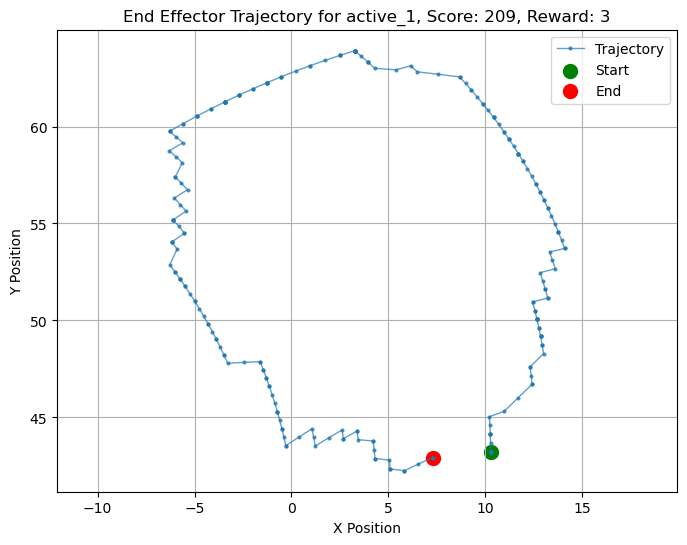

In [23]:
plot_trajectory(active_1)

In [25]:
def plot_trajectory_for_all_dfs(dfs, x_col='x', y_col='y'):
    """
    Plots the trajectory of the end effector from its (x, y) coordinates for every df in dfs.
    
    Parameters:
    - dfs: Dictionary of pandas DataFrames and their names, containing x and y columns
    - x_col: name of the x-coordinate column
    - y_col: name of the y-coordinate column
    """
    
    for df_name, df in dfs.items():
        x = df[x_col]
        y = df[y_col]
        # Get the row where df_name is the name of the current df
        row = rewards_df[rewards_df['df_name'] == df_name]

        # Extract reward and max_score
        reward = row['reward'].values[0]
        max_score = row['max_score'].values[0]
        
        plt.figure(figsize=(8, 6))
        plt.plot(x, y, marker='o', markersize=2, linewidth=1, alpha=0.7, label="Trajectory")
        
        # Highlight start and end points
        plt.scatter(x.iloc[0], y.iloc[0], color="green", s=100, label="Start")
        plt.scatter(x.iloc[-1], y.iloc[-1], color="red", s=100, label="End")
        
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.title(f"End Effector Trajectory for {df_name}, Score: {max_score}, Reward: {reward}")
        plt.legend()
        plt.axis("equal")  # keeps aspect ratio consistent
        plt.grid(True)
        plt.show()

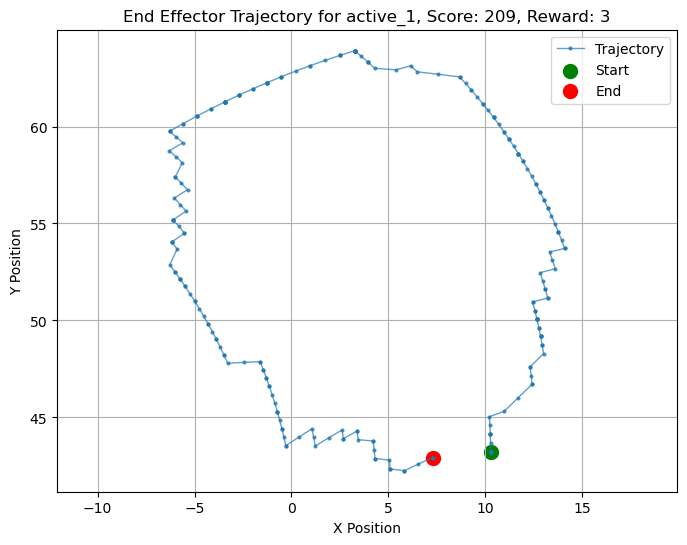

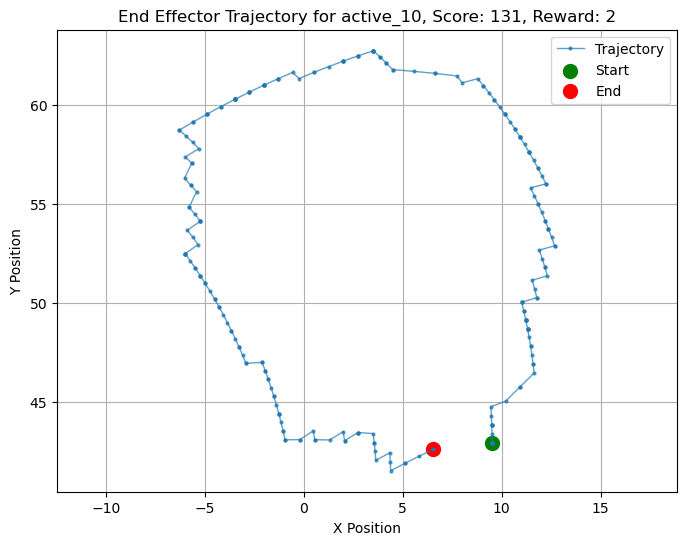

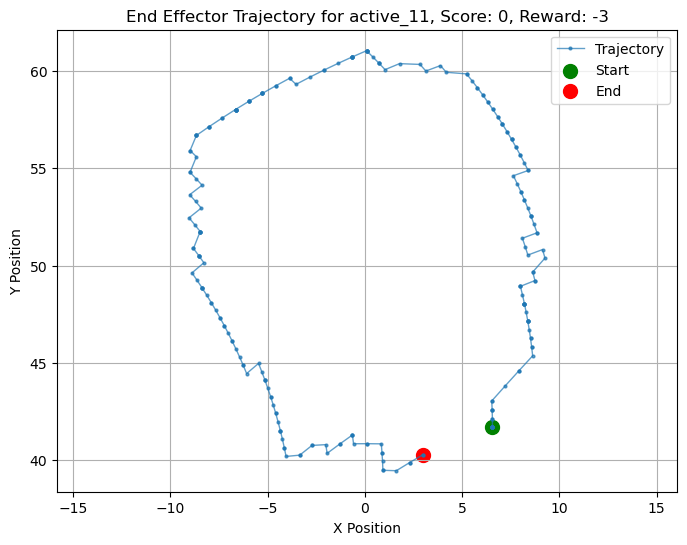

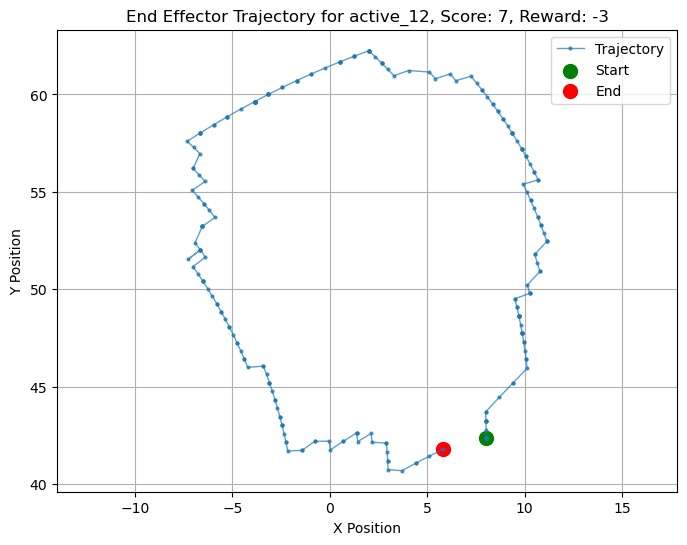

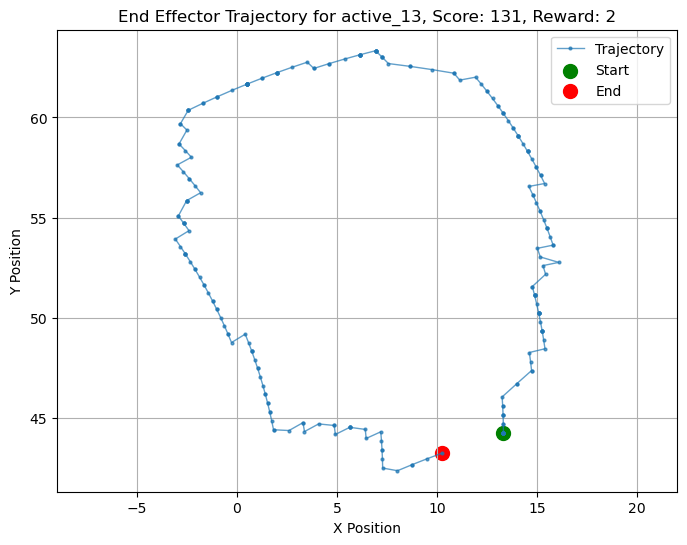

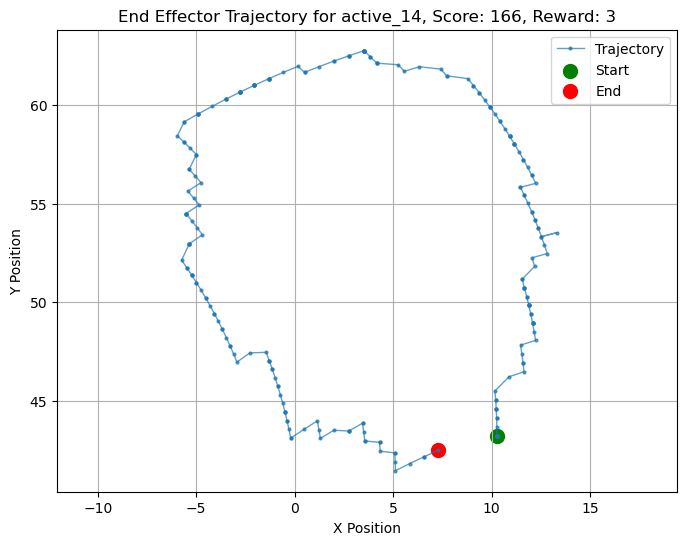

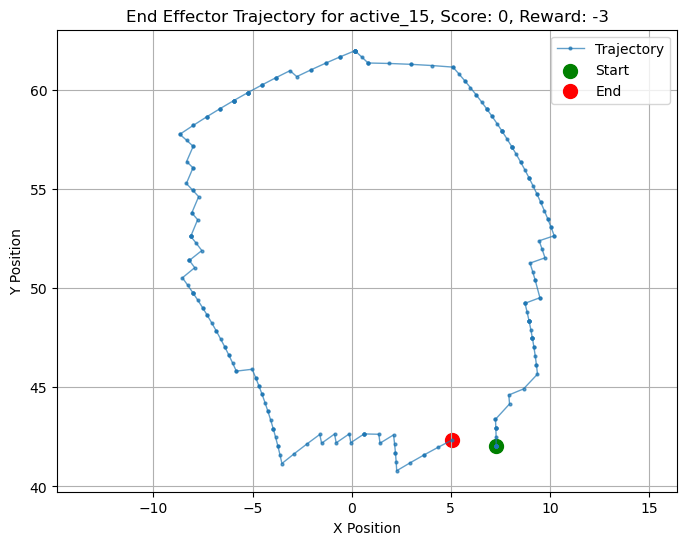

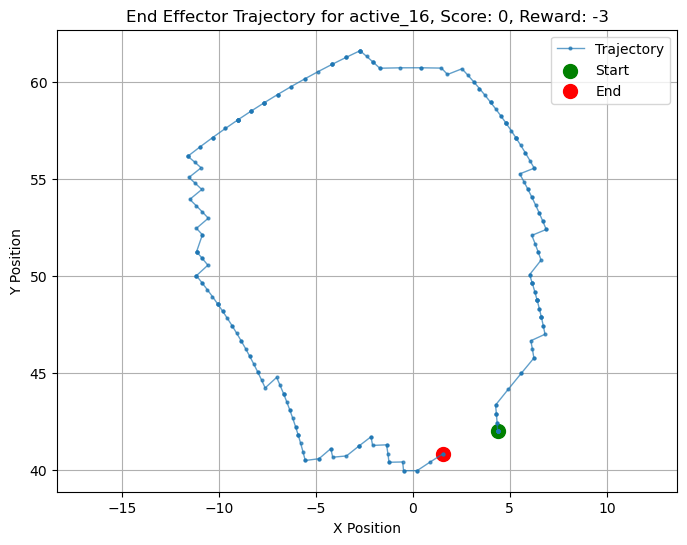

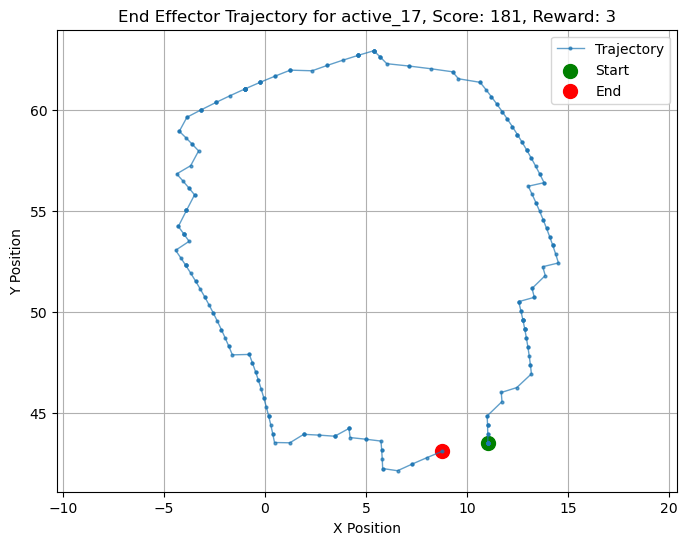

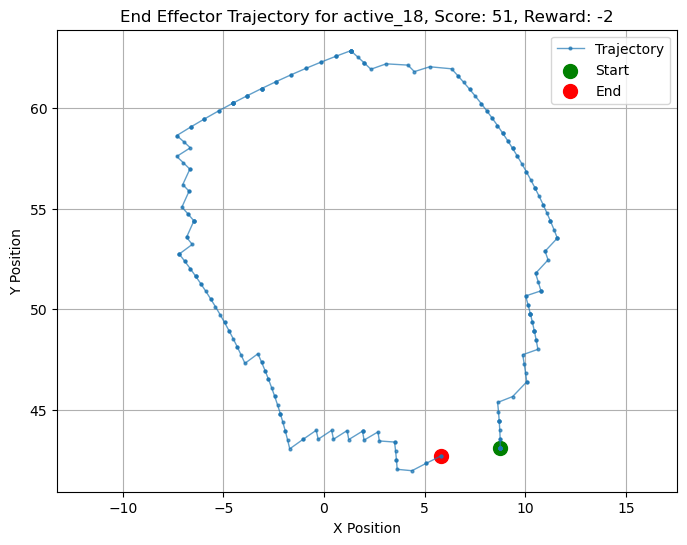

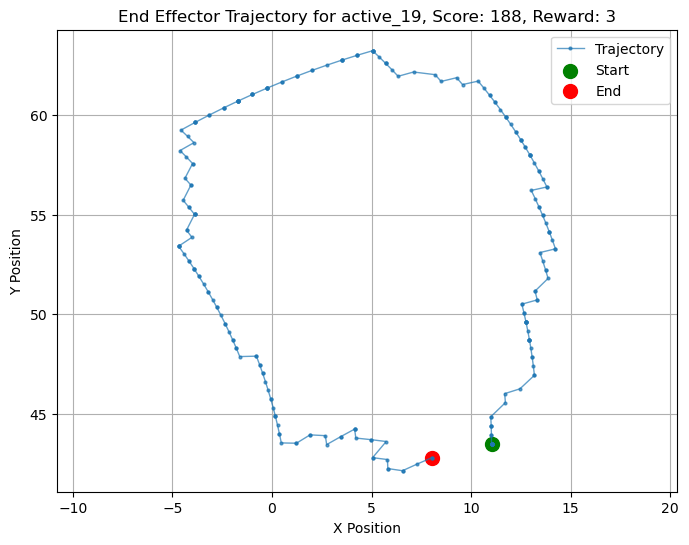

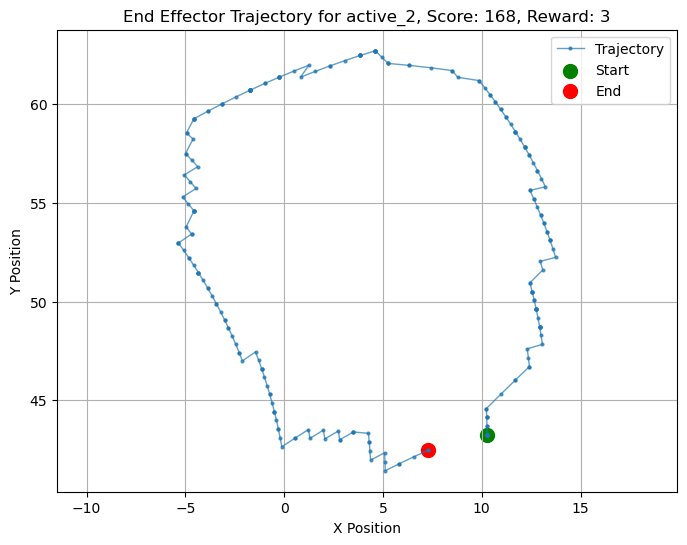

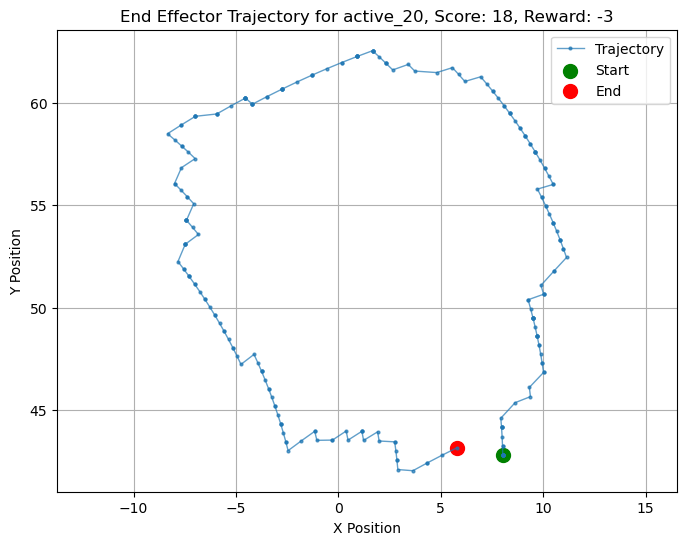

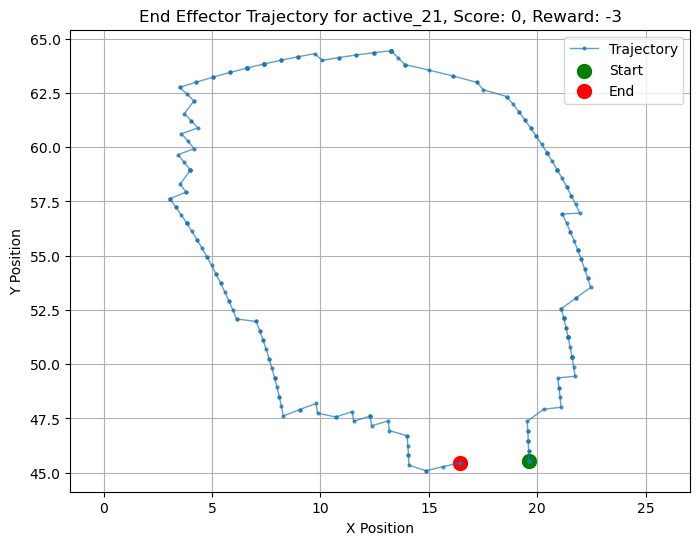

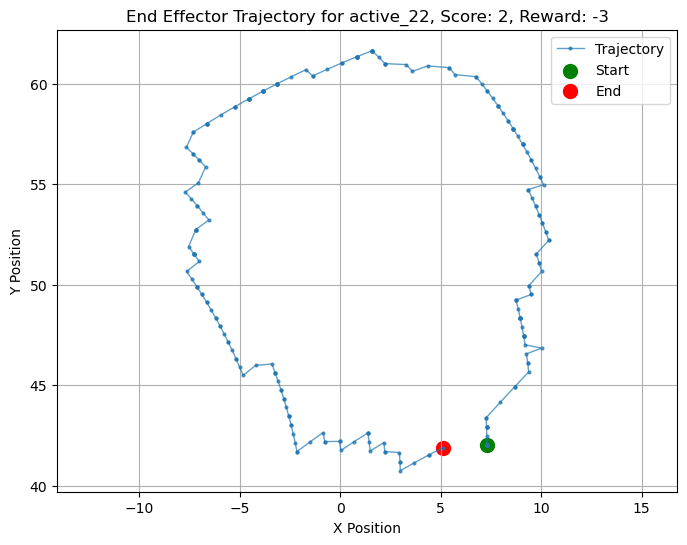

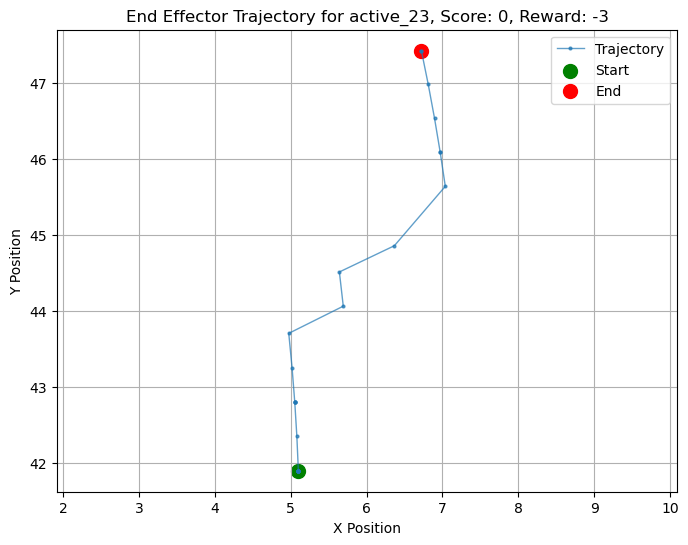

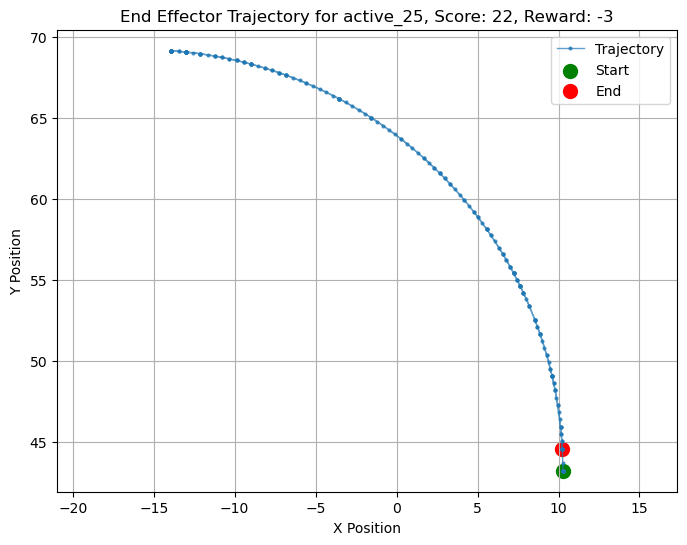

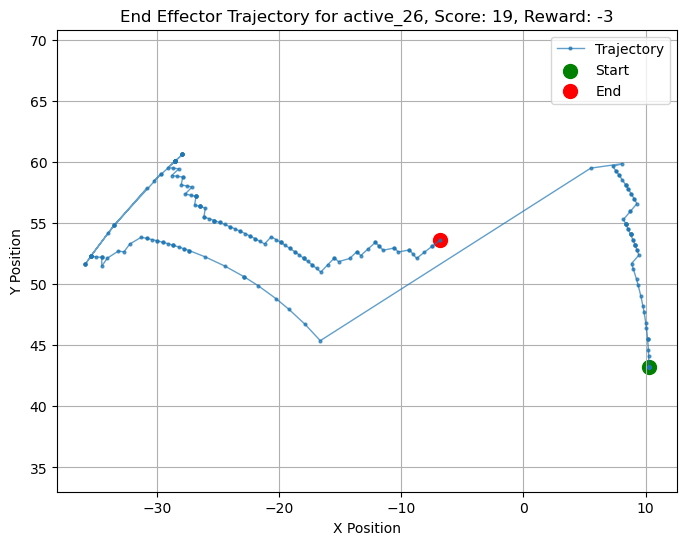

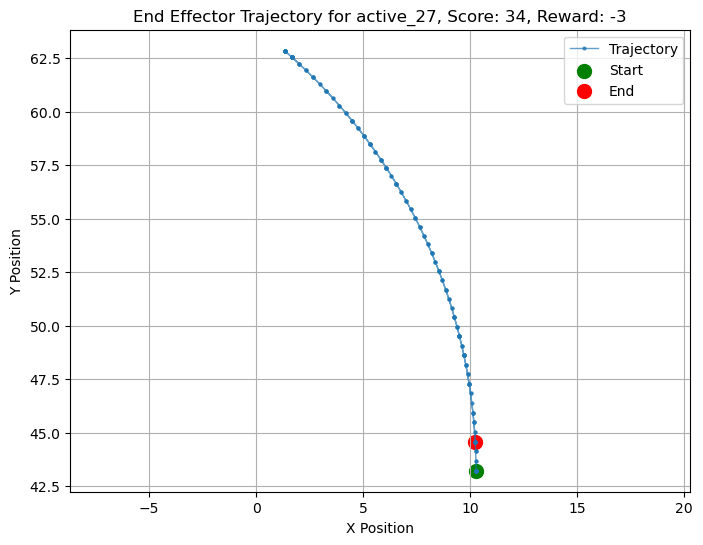

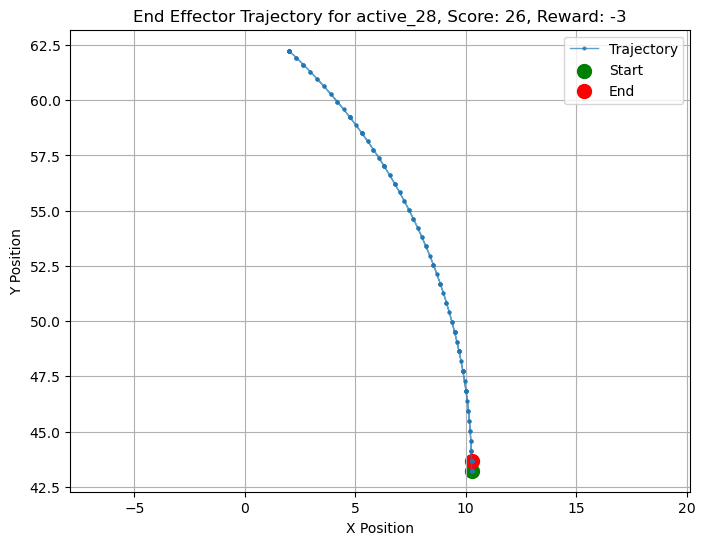

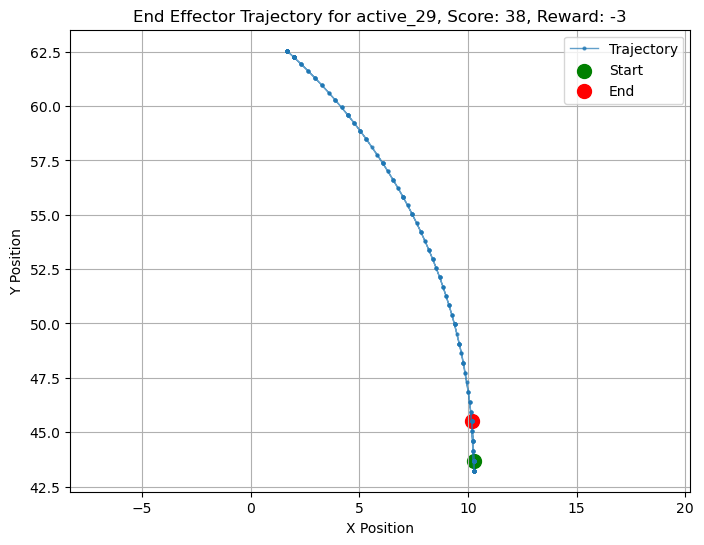

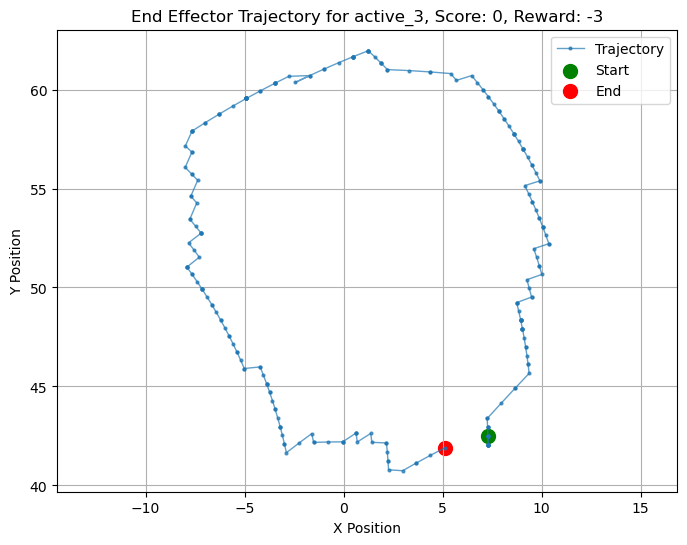

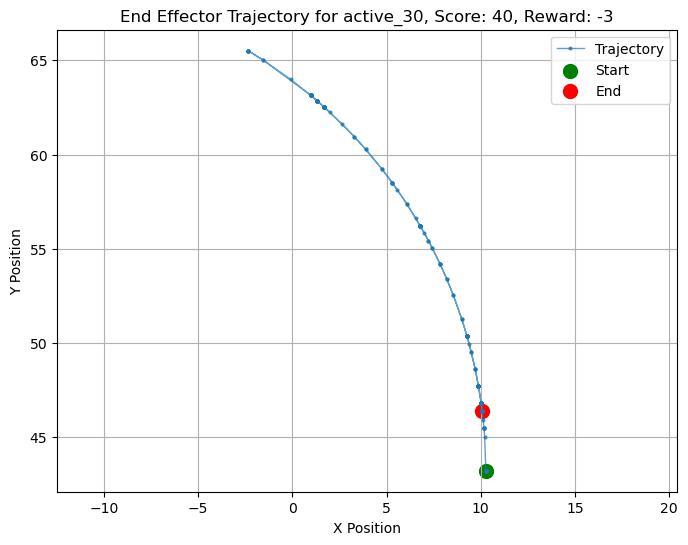

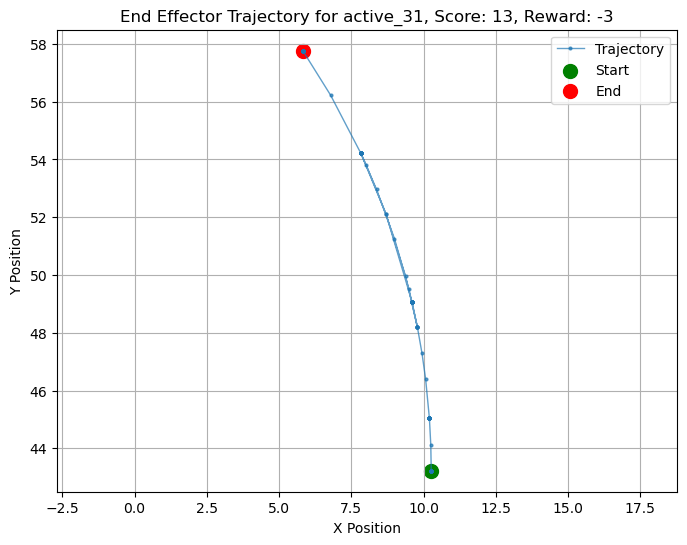

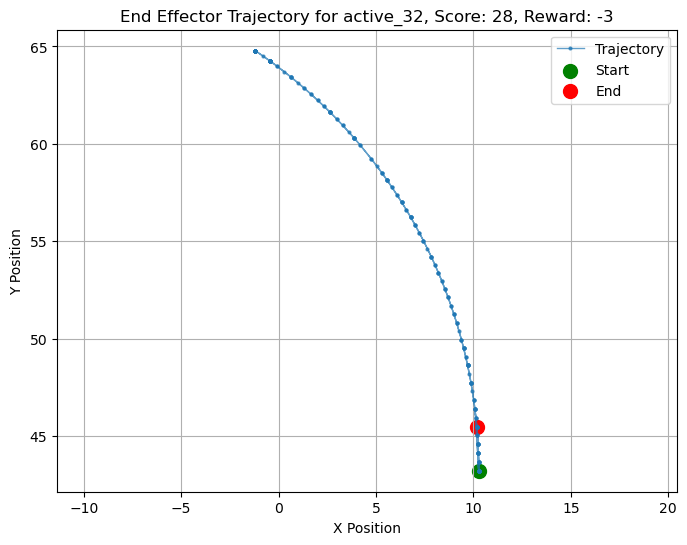

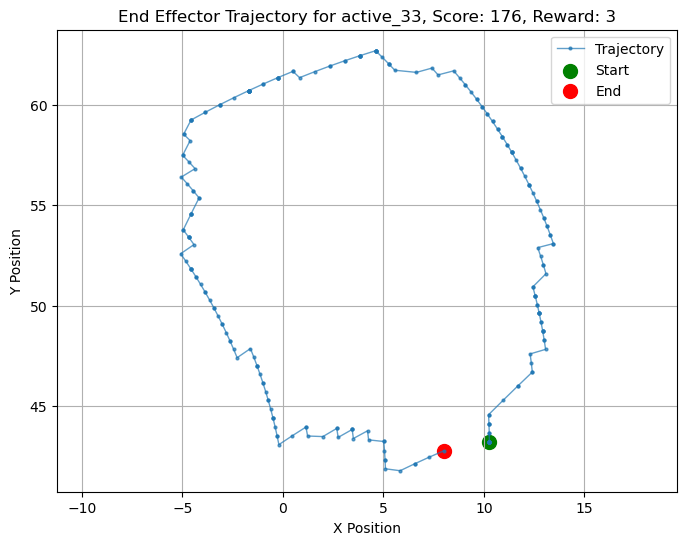

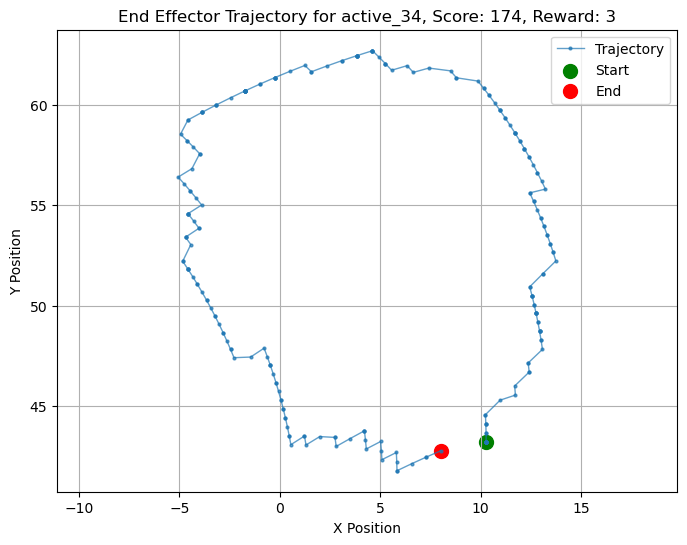

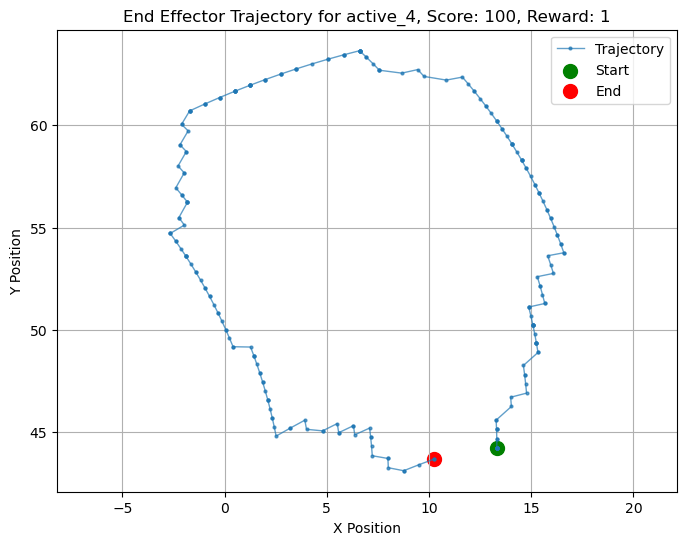

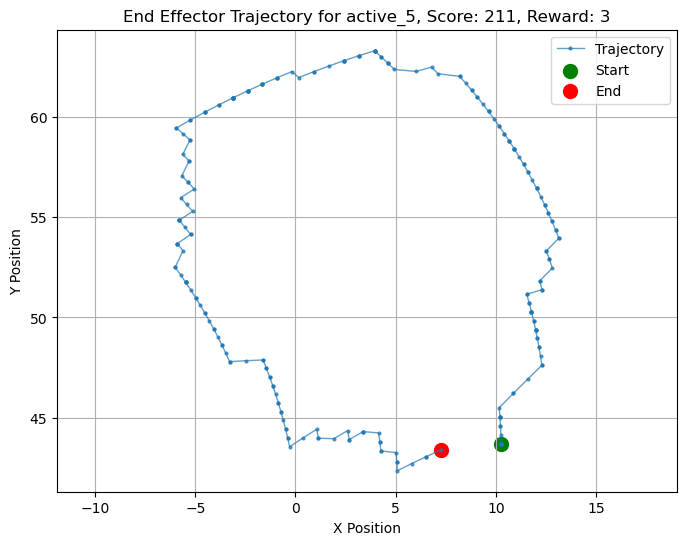

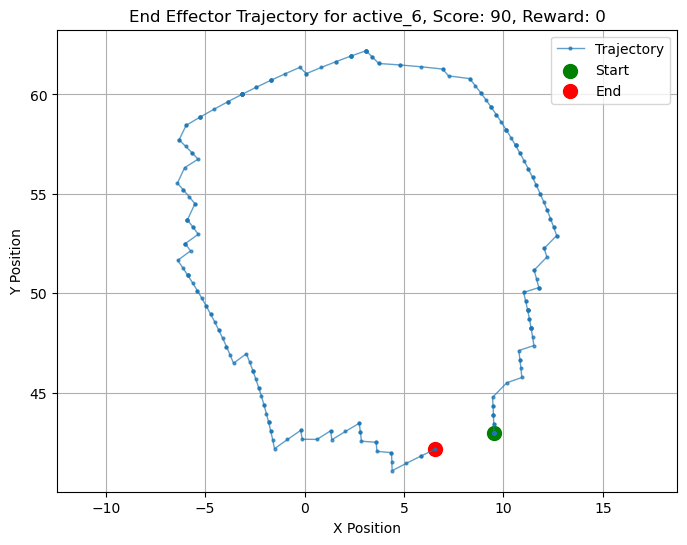

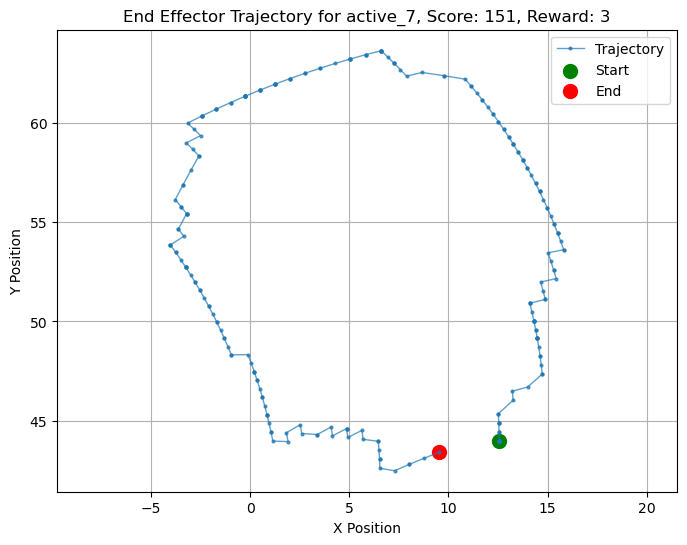

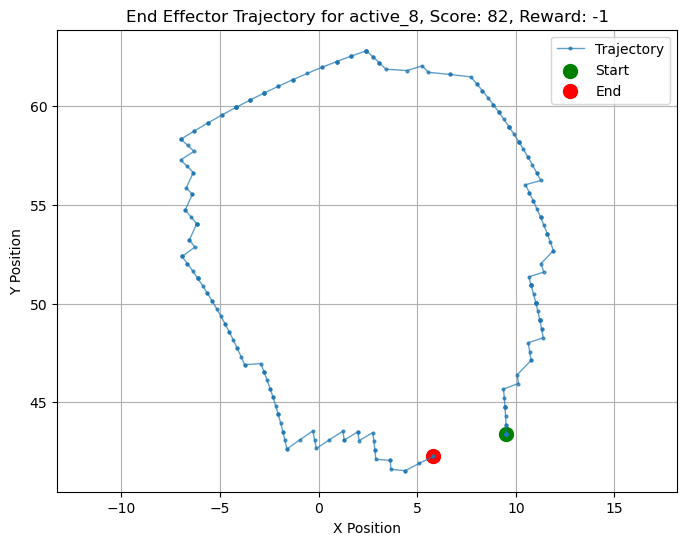

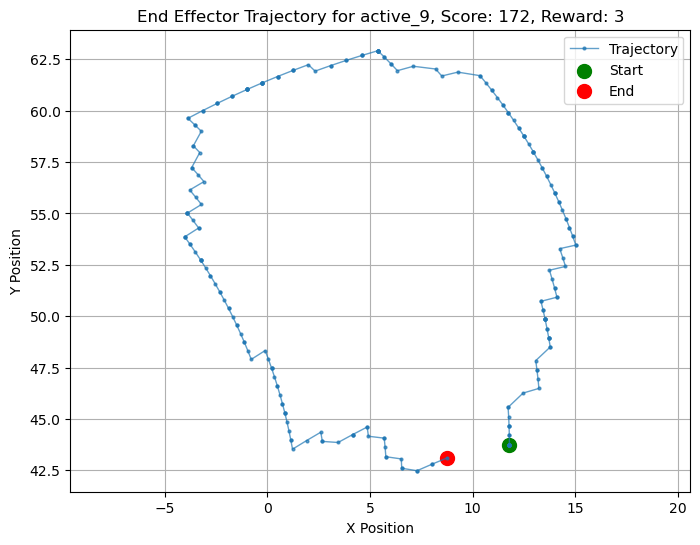

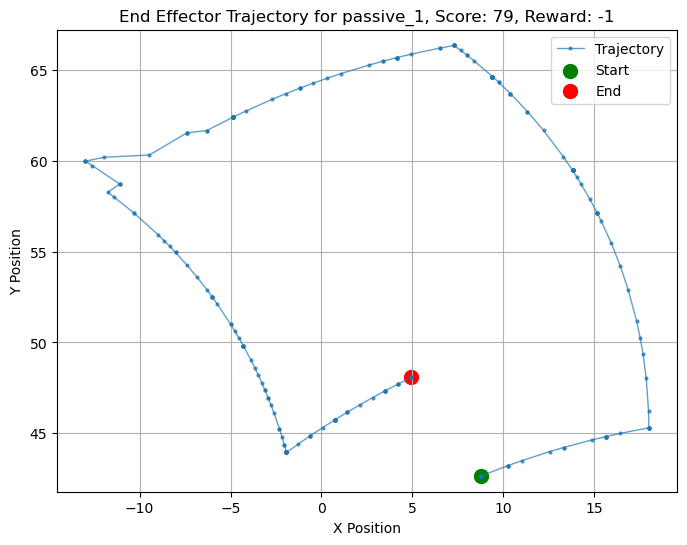

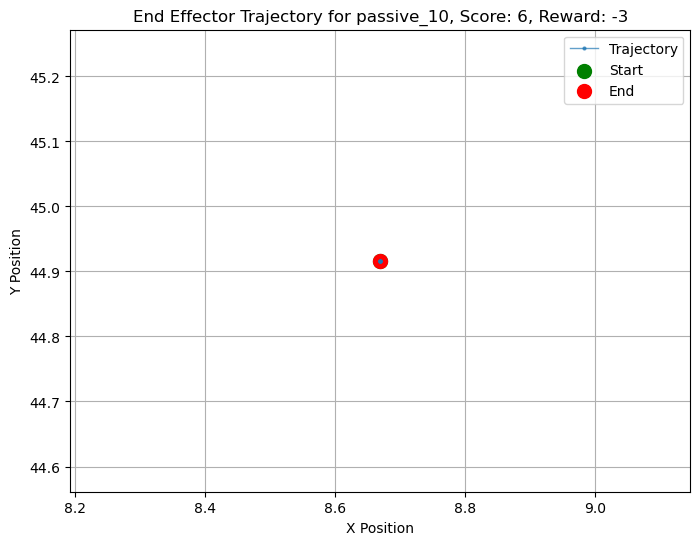

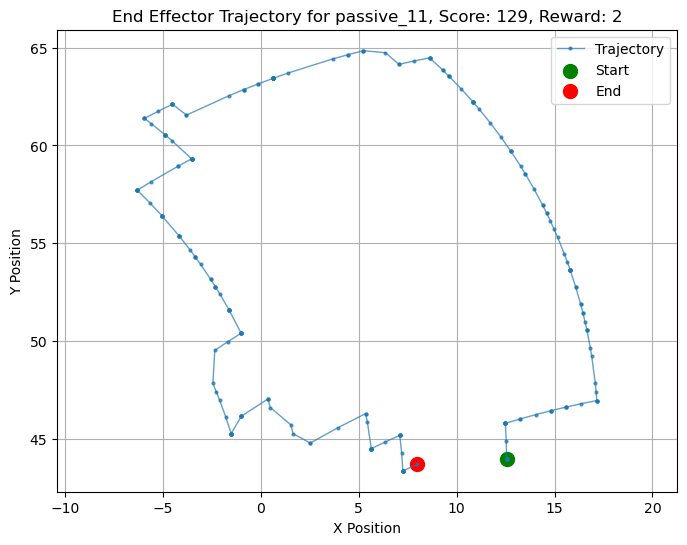

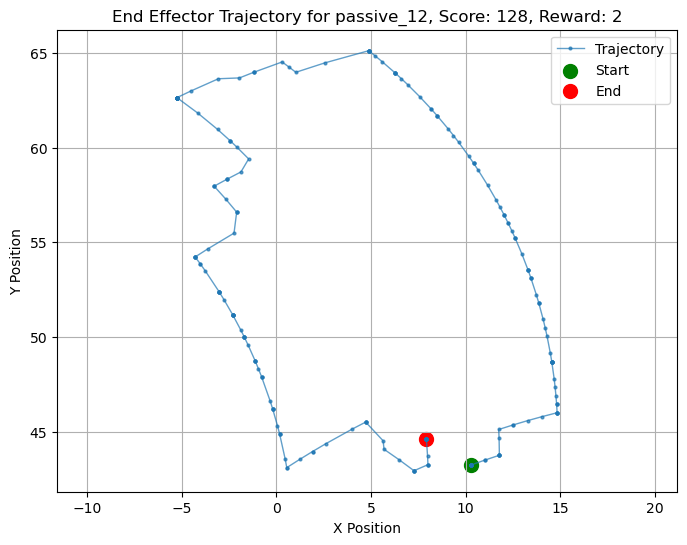

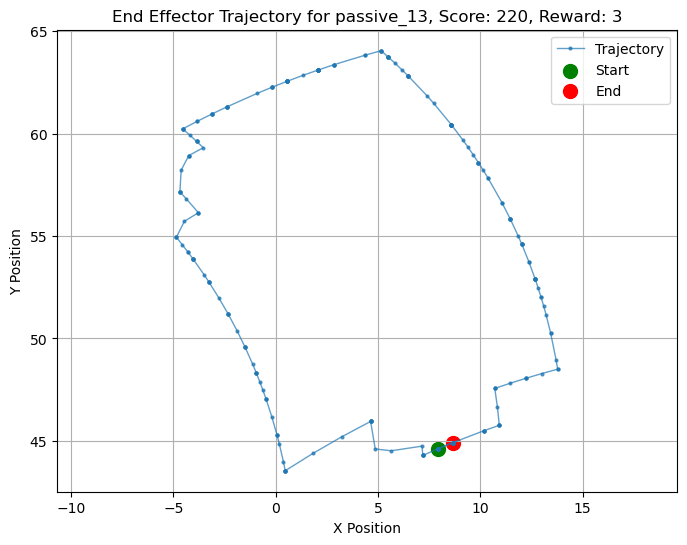

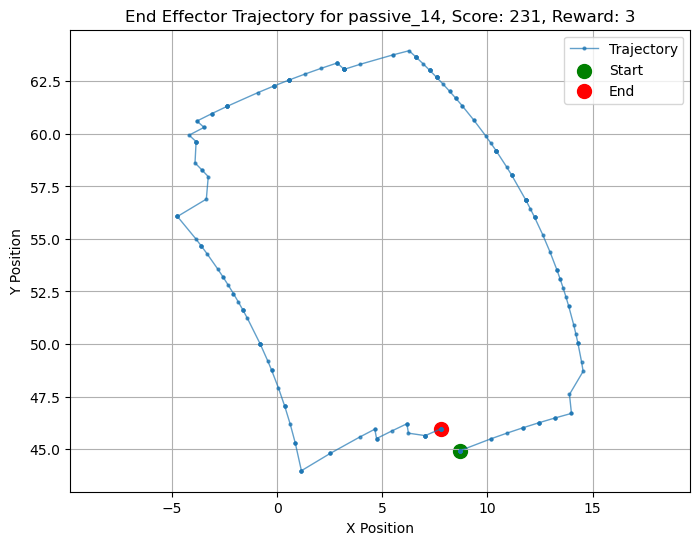

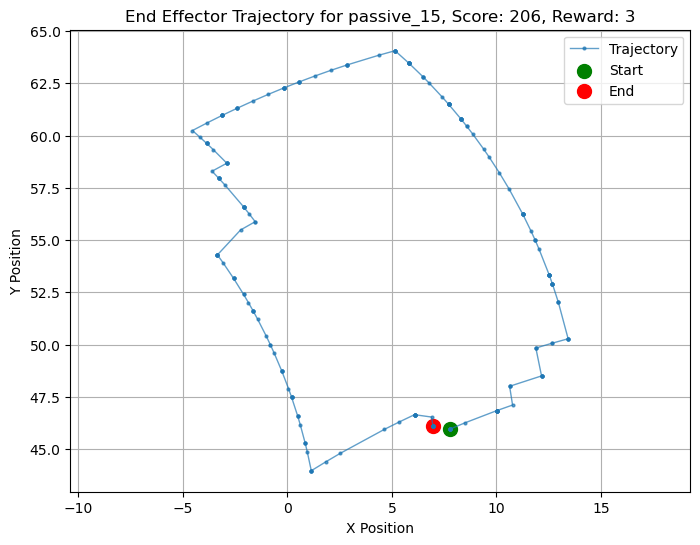

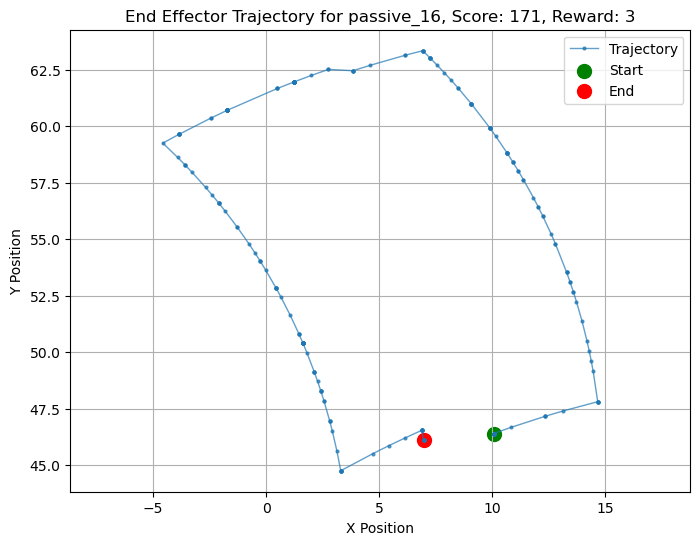

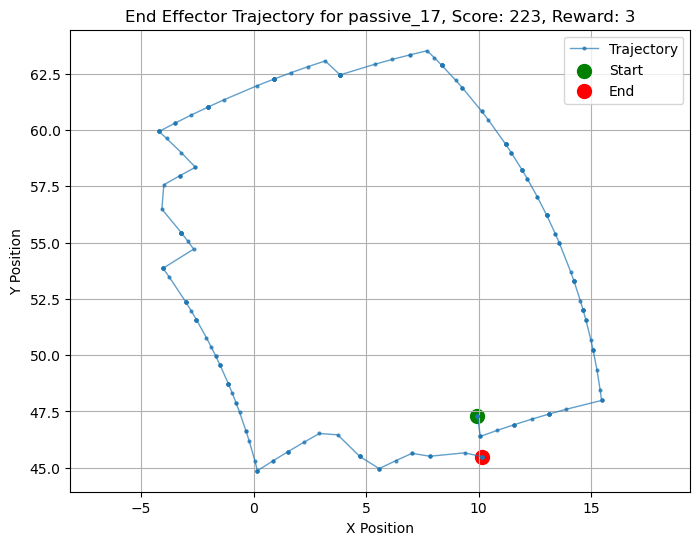

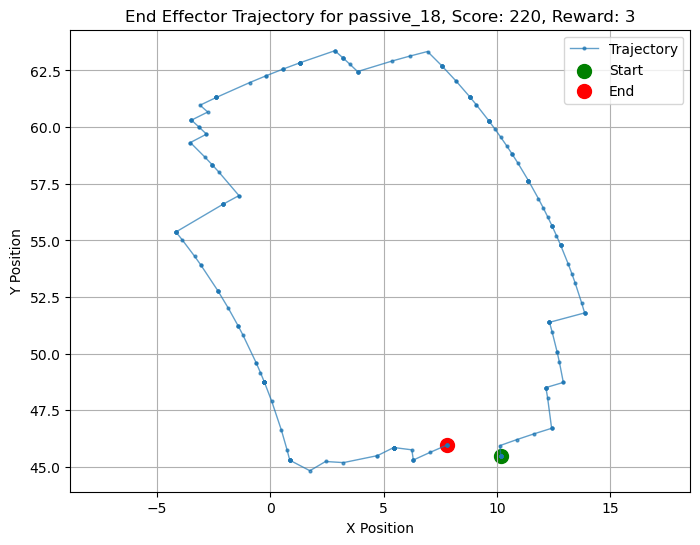

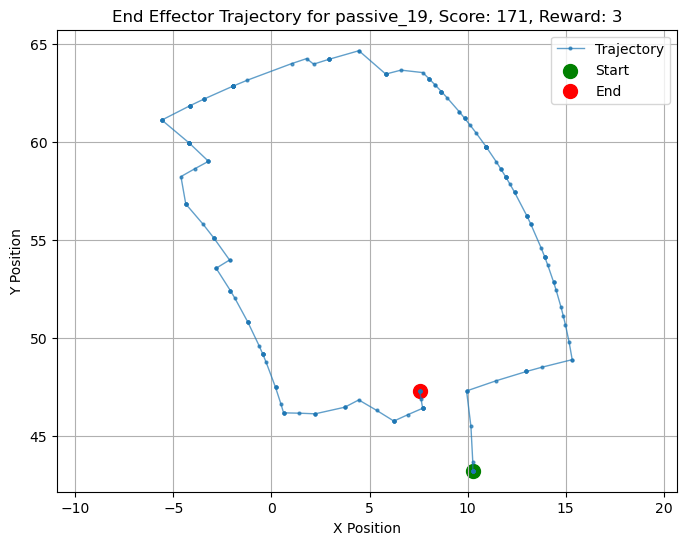

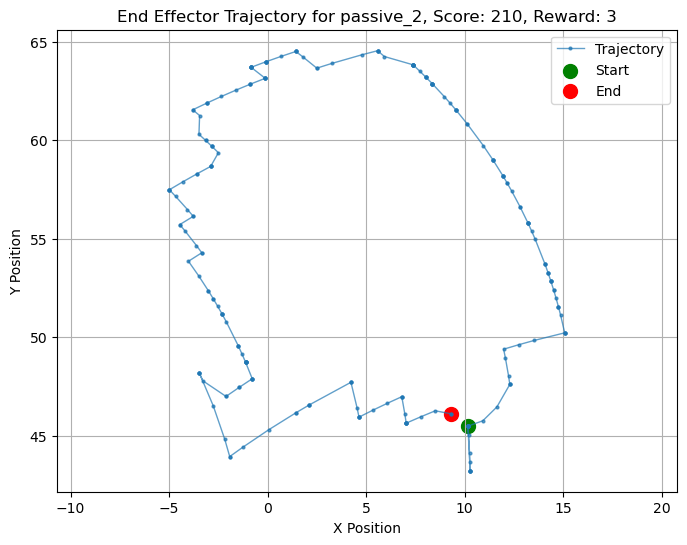

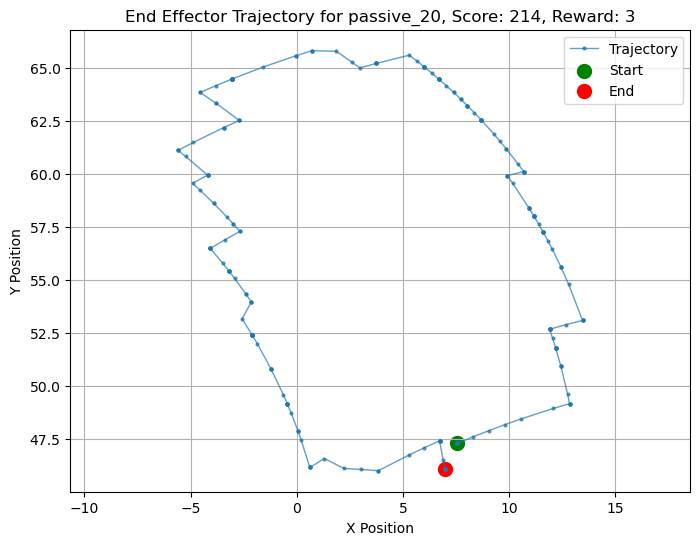

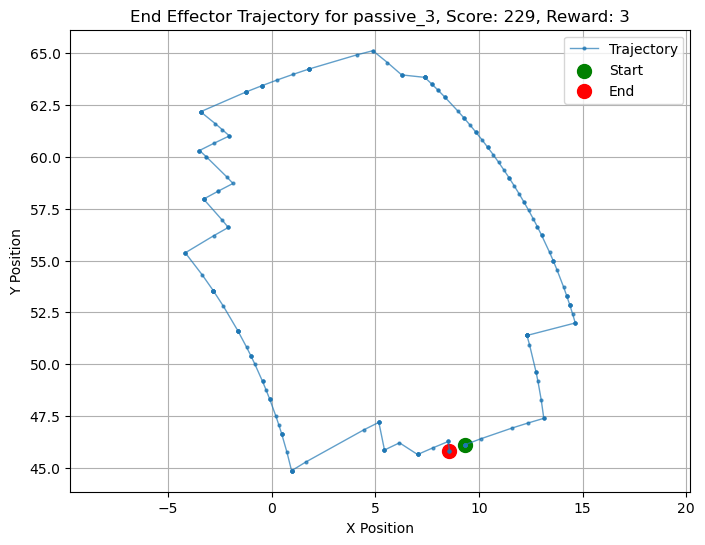

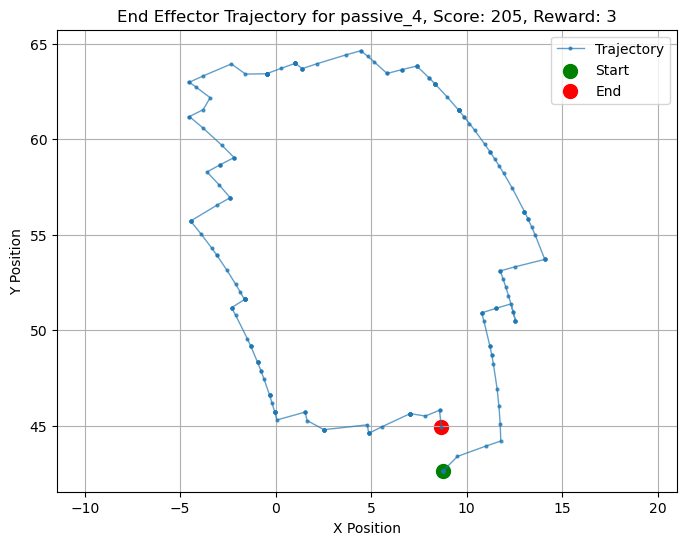

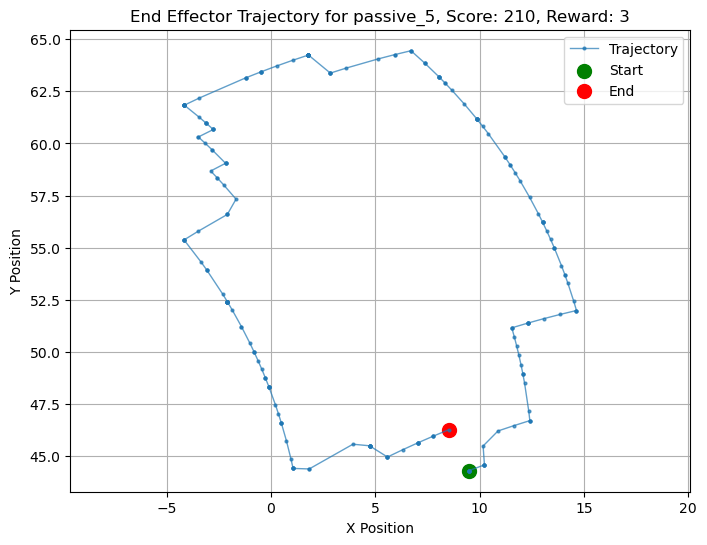

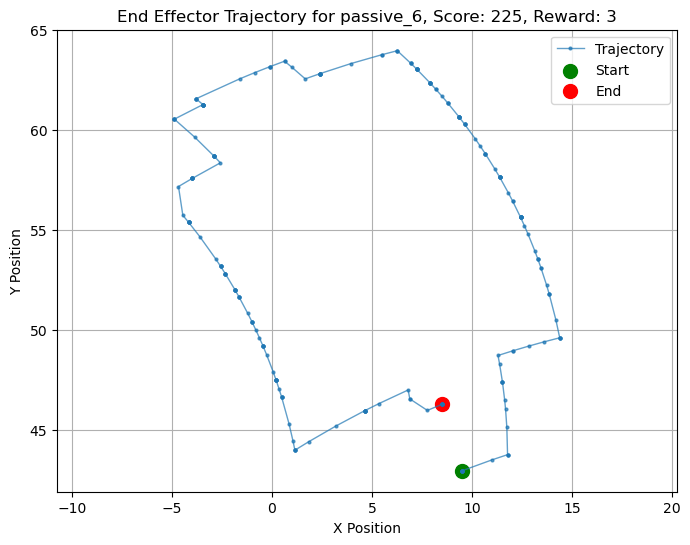

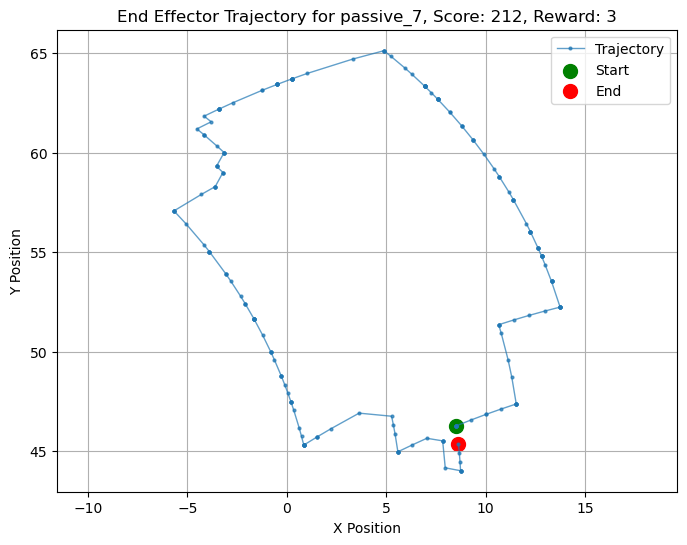

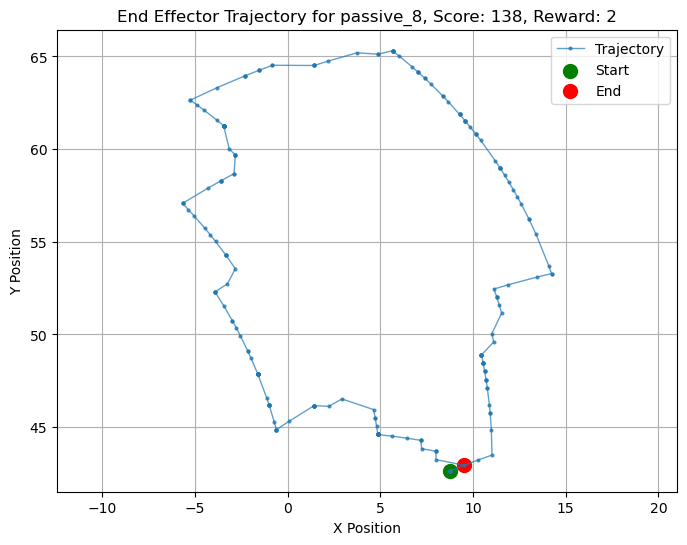

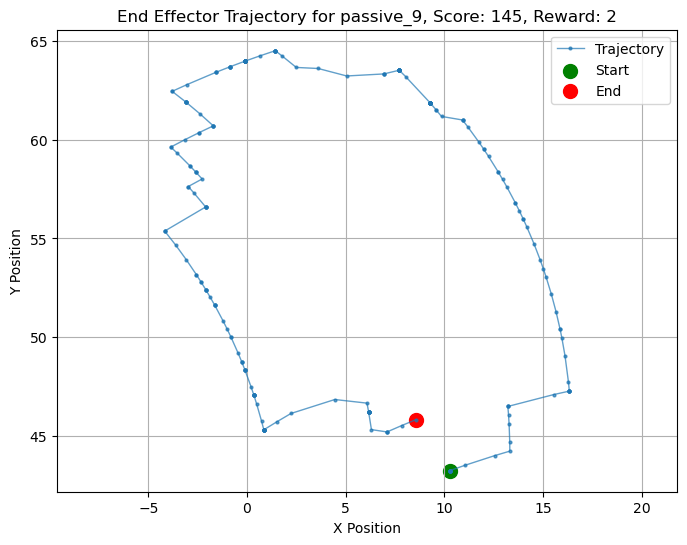

In [26]:
plot_trajectory_for_all_dfs(dataframes)

In [27]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def plot_trajectory_for_all_dfs(dfs, rewards_df, x_col='x', y_col='y', output_file="trajectories.pdf"):
    """
    Plots the trajectory of the end effector from its (x, y) coordinates for every df in dfs
    and saves all plots into a single PDF.

    Parameters:
    - dfs: Dictionary of pandas DataFrames and their names, containing x and y columns
    - rewards_df: DataFrame containing reward and max_score for each df_name
    - x_col: name of the x-coordinate column
    - y_col: name of the y-coordinate column
    - output_file: name of the output PDF file
    """
    
    with PdfPages(output_file) as pdf:
        for df_name, df in dfs.items():
            x = df[x_col]
            y = df[y_col]

            # Get the row where df_name matches
            row = rewards_df[rewards_df['df_name'] == df_name]
            
            if row.empty:
                reward, max_score = "N/A", "N/A"
            else:
                reward = row['reward'].values[0]
                max_score = row['max_score'].values[0]
            
            # Create plot
            plt.figure(figsize=(8, 6))
            plt.plot(x, y, marker='o', markersize=2, linewidth=1, alpha=0.7, label="Trajectory")
            
            # Highlight start and end points
            plt.scatter(x.iloc[0], y.iloc[0], color="green", s=100, label="Start")
            plt.scatter(x.iloc[-1], y.iloc[-1], color="red", s=100, label="End")
            
            plt.xlabel("X Position")
            plt.ylabel("Y Position")
            plt.title(f"Trajectory for {df_name} | Score: {max_score}, Reward: {reward}")
            plt.legend()
            plt.axis("equal")
            plt.grid(True)
            
            # Save this figure to the PDF
            pdf.savefig()
            plt.close()
    
    print(f"All trajectories saved to {output_file}")


In [29]:
plot_trajectory_for_all_dfs(dataframes, rewards_df)

All trajectories saved to trajectories.pdf
